<a href="https://colab.research.google.com/github/pchnqoc/TH_DeepLearning/blob/main/LAB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cài đặt và kiểm tra các thư viện dùng trong bài Lab 2
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Phiên bản TensorFlow hiện tại:", tf.__version__)

Phiên bản TensorFlow hiện tại: 2.20.0


In [2]:
print("--- ĐANG XỬ LÝ BÀI 1: CIFAR10 ---")
# 1. Tải bộ dữ liệu CIFAR10 có sẵn trong thư viện [cite: 445]
cifar10 = tf.keras.datasets.cifar10
(X_train_c10, y_train_c10), (X_test_c10, y_test_c10) = cifar10.load_data()

# 2. Chuẩn hóa dữ liệu ảnh về khoảng [0, 1]
X_train_c10 = X_train_c10 / 255.0
X_test_c10 = X_test_c10 / 255.0

# 3. Xây dựng kiến trúc mô hình ANN
model_cifar10 = Sequential([
    Flatten(input_shape=(32, 32, 3)), # Chuyển ảnh màu 32x32x3 thành vector phẳng
    Dense(512, activation='relu'),   # Hàm kích hoạt ReLU giúp học mẫu phi tuyến [cite: 52, 53]
    Dropout(0.2),                     # Dropout ngẫu nhiên gán 0 để tránh overfit [cite: 103, 105]
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')   # 10 lớp tương ứng với 10 nhãn phân loại từ 0-9 [cite: 445]
])

# 4. Biên dịch mô hình sử dụng hàm optimizer Adam [cite: 255]
model_cifar10.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Huấn luyện mô hình
print("Bắt đầu huấn luyện CIFAR10...")
history_c10 = model_cifar10.fit(
    X_train_c10, y_train_c10,
    validation_split=0.2,
    epochs=10, # Bạn có thể tăng số epoch lên 20-30 nếu muốn độ chính xác cao hơn
    batch_size=64,
    verbose=1
)

# 6. Đánh giá trên tập kiểm thử
test_loss, test_acc = model_cifar10.evaluate(X_test_c10, y_test_c10, verbose=0)
print(f"=> Độ chính xác trên tập test (CIFAR10): {test_acc*100:.2f}%\n")

--- ĐANG XỬ LÝ BÀI 1: CIFAR10 ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 103s 1us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Bắt đầu huấn luyện CIFAR10...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.2664 - loss: 2.0037 - val_accuracy: 0.3242 - val_loss: 1.8630
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.3277 - loss: 1.8388 - val_accuracy: 0.3639 - val_loss: 1.7831
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.3442 - loss: 1.8005 - val_accuracy: 0.3759 - val_loss: 1.7298
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3631 - loss: 1.7564 - val_accuracy: 0.4047 - val_loss: 1.6949
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.3717 - loss: 1.7353 - val_accuracy: 0.3975 - val_loss: 1.6843
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.3829 - loss: 1.7110 - val_accuracy: 0.4054 - val_loss: 1.6575
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.3878 - loss: 1.6897 - val_accuracy: 0.4179 - val_loss: 1.6484
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accu

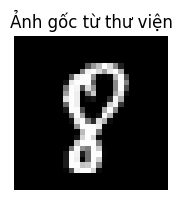

 Nhãn thực tế của ảnh (True Label): 8
 Mạng ANN nhận diện là (Prediction): 8
Độ tự tin: 99.55%


In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Tải bộ dữ liệu MNIST từ thư viện
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Chuẩn hóa tập train và tập test
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# 2. Định nghĩa và huấn luyện nhanh mô hình
model_mnist = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model_mnist.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_mnist.fit(X_train_norm, y_train, epochs=2, batch_size=64, verbose=0)

# ========================================================
# HÀNH ĐỘNG: LẤY NGẪU NHIÊN 1 ẢNH TRONG THƯ VIỆN ĐỂ NHẬN DIỆN
# ========================================================
random_idx = random.randint(0, len(X_test) - 1)

test_image = X_test[random_idx]
normalized_image = X_test_norm[random_idx]
true_label = y_test[random_idx]

# Hiển thị ảnh vừa bốc được ra màn hình
plt.figure(figsize=(2,2))
plt.imshow(test_image, cmap='gray')
plt.title(f"Ảnh gốc từ thư viện")
plt.axis('off')
plt.show()

# --- SỬA LẠI DÒNG NÀY ---
# Thay vì reshape(1, 784), ta giữ nguyên (28, 28) và thêm chiều batch thành (1, 28, 28)
img_input = normalized_image.reshape(1, 28, 28)

# Mô hình tự dự đoán (Tầng Flatten sẽ tự động xử lý vector 784 bên trong)
prediction = model_mnist.predict(img_input, verbose=0)
predicted_digit = np.argmax(prediction)

print(f" Nhãn thực tế của ảnh (True Label): {true_label}")
print(f" Mạng ANN nhận diện là (Prediction): {predicted_digit}")
print(f"Độ tự tin: {prediction[0][predicted_digit]*100:.2f}%")

In [16]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("--- ĐANG XỬ LÝ BÀI 4: DATASET ADULT ---")

# 1. Tải bộ dữ liệu Adult thực tế về Colab
url_adult = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]
df_adult = pd.read_csv(url_adult, names=columns, sep=",\s*", engine="python")

# 2. Tiền xử lý dữ liệu bảng
# Chuyển đổi các cột dữ liệu dạng chữ (Categorical) sang dạng số bằng One-Hot Encoding
X_adult = df_adult.drop(columns=["income"])
X_adult = pd.get_dummies(X_adult)

# Mã hóa nhãn đầu ra (income) thành nhị phân: <=50K -> 0, >50K -> 1
le_adult = LabelEncoder()
y_adult = le_adult.fit_transform(df_adult["income"])

# 3. Chia tập dữ liệu thành Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_adult, y_adult, test_size=0.2, random_state=42)

# Chuẩn hóa đặc trưng (Feature Scaling) để các cột có giá trị lệch nhau học ổn định hơn
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Xây dựng cấu trúc mạng mạng ANN phân loại nhị phân
model_adult = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'), # Tầng vào nhận số lượng đặc trưng
    Dropout(0.2),
    Dense(32, activation='relu'),                             # Tầng ẩn
    Dense(1, activation='sigmoid')                            # Đầu ra 1 neuron với Sigmoid ra xác suất nhị phân
])

# 5. Biên dịch mô hình với loss binary_crossentropy cho phân loại 2 lớp
model_adult.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Huấn luyện mô hình
print("Bắt đầu huấn luyện mô hình dự báo thu nhập...")
model_adult.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test))

# 7. Đánh giá kết quả trên tập Test
loss, acc = model_adult.evaluate(X_test, y_test, verbose=0)
print(f"\n=> Độ chính xác dự báo thu nhập trên tập Test: {acc*100:.2f}%")

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_603/1866795782.py:18: SyntaxWarning: invalid escape sequence '\s'
  df_adult = pd.read_csv(url_adult, names=columns, sep=",\s*", engine="python")


--- ĐANG XỬ LÝ BÀI 4: DATASET ADULT ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Bắt đầu huấn luyện mô hình dự báo thu nhập...
Epoch 1/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8250 - loss: 0.3741 - val_accuracy: 0.8489 - val_loss: 0.3269
Epoch 2/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8446 - loss: 0.3309 - val_accuracy: 0.8541 - val_loss: 0.3215
Epoch 3/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8504 - loss: 0.3202 - val_accuracy: 0.8566 - val_loss: 0.3156
Epoch 4/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8516 - loss: 0.3155 - val_accuracy: 0.8583 - val_loss: 0.3142
Epoch 5/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8544 - loss: 0.3109 - val_accuracy: 0.8555 - val_loss: 0.3143
Epoch 6/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8559 - loss: 0.3064 - val_accuracy: 0.8606 - val_loss: 0.3118
Epoch 7/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8567 - loss: 0.3054 - val_accuracy: 0.8587 - val_loss: 0.3101
Epoch 8/10
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc

In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("--- ĐANG XỬ LÝ BÀI 5: DATASET CAR EVALUATION ---")

# 1. Tải bộ dữ liệu Car Evaluation thực tế về Colab
url_car = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
car_columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df_car = pd.read_csv(url_car, names=car_columns)

# 2. Tiền xử lý dữ liệu đặc trưng dạng bảng
# Chuyển đổi các đặc trưng dạng chữ sang các cột số số bằng One-Hot Encoding
X_car = df_car.drop(columns=["class"])
X_car = pd.get_dummies(X_car)

# Mã hóa nhãn phân loại chất lượng xe thành các số nguyên từ 0 đến 3
le_car = LabelEncoder()
y_car = le_car.fit_transform(df_car["class"])

# Lấy số lượng lớp nhãn thực tế (4 lớp)
num_classes = len(np.unique(y_car))

# 3. Chia tập dữ liệu thành Train (80%) và Test (20%)
X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(X_car, y_car, test_size=0.2, random_state=42)

# 4. Xây dựng cấu trúc mạng mạng ANN phân loại đa lớp
model_car = Sequential([
    Dense(64, input_dim=X_train_car.shape[1], activation='relu'), # Tầng vào
    Dense(32, activation='relu'),                                 # Tầng ẩn
    Dense(num_classes, activation='softmax')                      # Tầng ra gồm 4 lớp dùng Softmax
])

# 5. Biên dịch mô hình đa lớp dùng loss sparse_categorical_crossentropy
model_car.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Huấn luyện mô hình
print("Bắt đầu huấn luyện mô hình đánh giá chất lượng xe...")
model_car.fit(X_train_car, y_train_car, epochs=15, batch_size=32, validation_data=(X_test_car, y_test_car))

# 7. Đánh giá kết quả trên tập Test
loss_car, acc_car = model_car.evaluate(X_test_car, y_test_car, verbose=0)
print(f"\n=> Độ chính xác phân loại chất lượng xe trên tập Test: {acc_car*100:.2f}%")

# 8. Dự đoán thử nghiệm một mẫu xe đầu tiên trong tập kiểm thử
print("\n--- DỰ ĐOÁN THỬ NGHIỆM MỘT MẪU XE ---")
sample_input = np.expand_dims(X_test_car.iloc[0], axis=0)
pred = model_car.predict(sample_input, verbose=0)
pred_class_idx = np.argmax(pred)

print(f" Kết quả thực tế (True Label): {le_car.classes_[y_test_car[0]]}")
print(f" Mạng ANN chẩn đoán là (Prediction): {le_car.classes_[pred_class_idx]}")

--- ĐANG XỬ LÝ BÀI 5: DATASET CAR EVALUATION ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Bắt đầu huấn luyện mô hình đánh giá chất lượng xe...
Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6599 - loss: 0.9178 - val_accuracy: 0.6792 - val_loss: 0.7828
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7135 - loss: 0.6527 - val_accuracy: 0.7225 - val_loss: 0.6067
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8003 - loss: 0.4787 - val_accuracy: 0.8208 - val_loss: 0.4155
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8734 - loss: 0.3321 - val_accuracy: 0.8844 - val_loss: 0.2901
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9103 - loss: 0.2513 - val_accuracy: 0.9220 - val_loss: 0.2276
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9349 - loss: 0.2043 - val_accuracy: 0.9335 - val_loss: 0.1906
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9457 - loss: 0.1706 - val_accuracy: 0.9624 - val_loss: 0.1584
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.

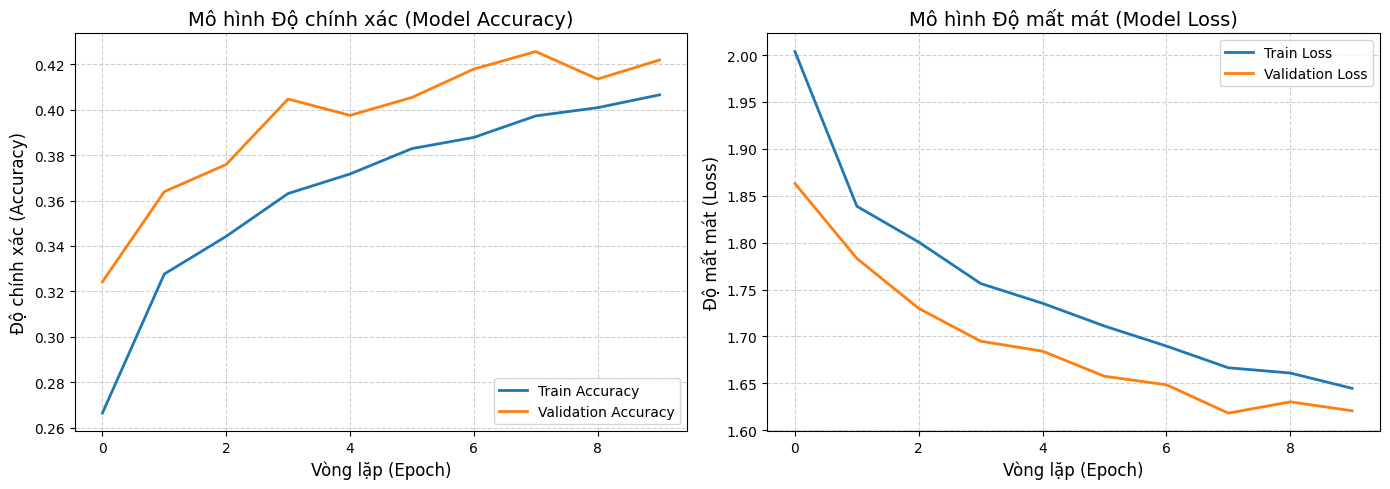

In [18]:
import matplotlib.pyplot as plt

# ========================================================
# 1. VẼ BIỂU ĐỒ ĐỘ CHÍNH XÁC (MODEL ACCURACY)
# ========================================================
plt.figure(figsize=(14, 5))

# Tạo đồ thị con bên trái cho Accuracy
plt.subplot(1, 2, 1)
# 'history_c10' hoặc 'history' là biến lưu kết quả khi bạn chạy model.fit()
# Nếu dùng cho bài Chó/Mèo, bạn đổi tên biến thành 'history' tương ứng nhé!
plt.plot(history_c10.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history_c10.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Mô hình Độ chính xác (Model Accuracy)', fontsize=14)
plt.ylabel('Độ chính xác (Accuracy)', fontsize=12)
plt.xlabel('Vòng lặp (Epoch)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6) # Thêm lưới cho dễ quan sát

# ========================================================
# 2. VẼ BIỂU ĐỒ ĐỘ MẤT MÁT (MODEL LOSS)
# ========================================================
# Tạo đồ thị con bên phải cho Loss
plt.subplot(1, 2, 2)
plt.plot(history_c10.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history_c10.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Mô hình Độ mất mát (Model Loss)', fontsize=14)
plt.ylabel('Độ mất mát (Loss)', fontsize=12)
plt.xlabel('Vòng lặp (Epoch)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# Hiển thị cặp biểu đồ lên màn hình Colab
plt.tight_layout()
plt.show()